# Repetition codes

Adapted from the IBM Quantum tutorial "Repetition codes".

Source page: https://qiskit.qotlabs.org/docs/tutorials/repetition-codes

> Runtime note: the original tutorial estimates less than 1 minute on a Heron processor, but actual runtime may vary.

## Background

To enable real-time quantum error correction (QEC), you need to dynamically control quantum program flow during execution so that quantum gates can be conditioned on measurement results.

This notebook runs the **bit-flip code**, a simple form of QEC. It demonstrates a dynamic quantum circuit that can protect an encoded qubit from a single bit-flip error, and then evaluates the bit-flip code performance.

A stabilizer code encodes logical qubits into physical qubits and uses ancilla qubits to measure stabilizers without collapsing the encoded logical information.

## Setup

In [1]:
# Qiskit imports
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

# Qiskit Runtime
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

service = QiskitRuntimeService()
from qiskit_ibm_runtime.fake_provider import FakeFez

backend = FakeFez()
# backend = service.least_busy()


## Step 1. Map classical inputs to a quantum problem

### Build a bit-flip stabilizer circuit

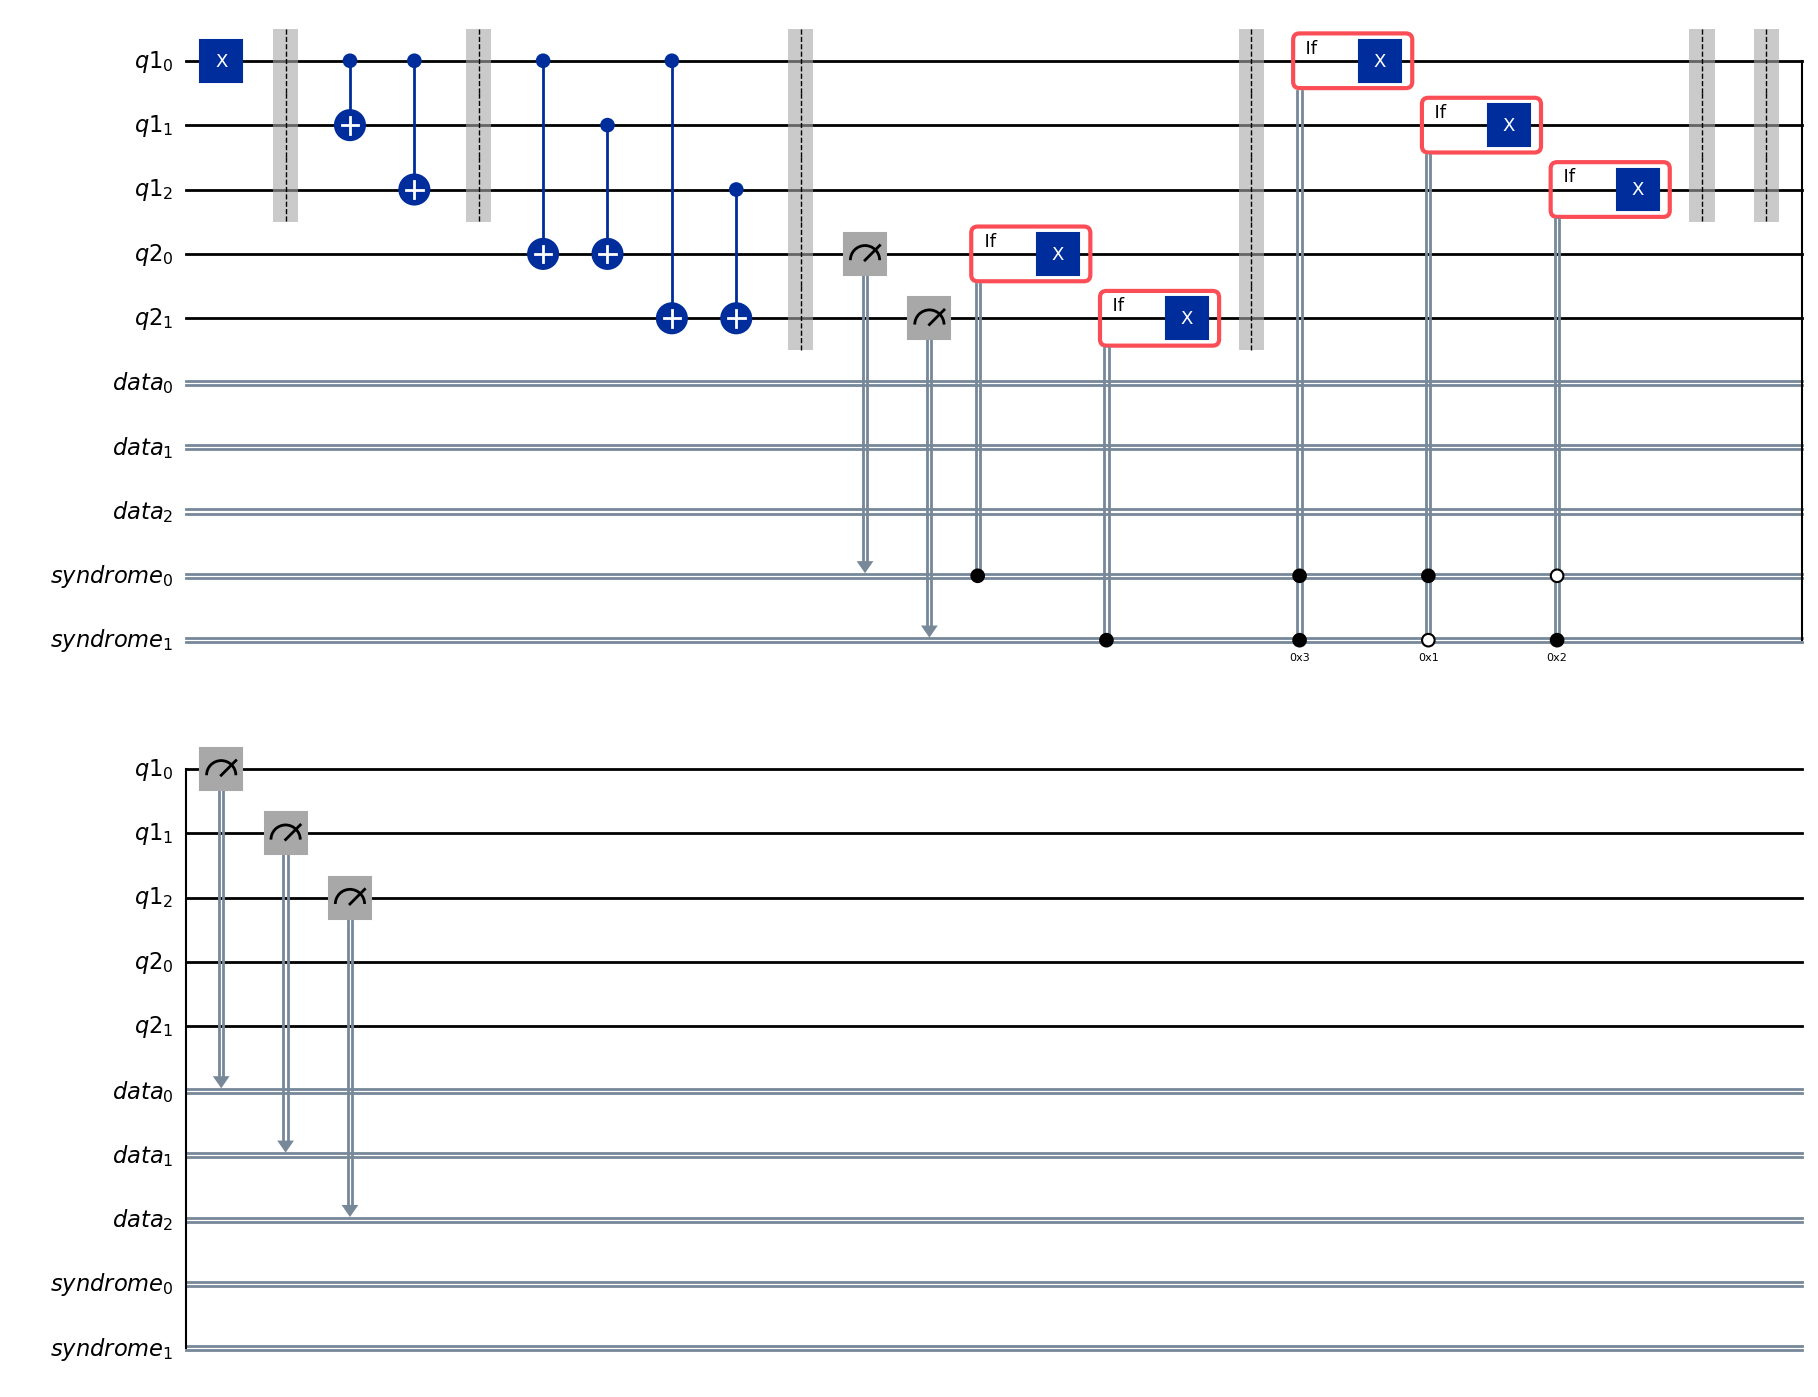

In [2]:
# Choose the least busy backend that supports `measure_2`.

qreg_data = QuantumRegister(3)
qreg_measure = QuantumRegister(2)
creg_data = ClassicalRegister(3, name="data")
creg_syndrome = ClassicalRegister(2, name="syndrome")
state_data = qreg_data[0]
ancillas_data = qreg_data[1:]


def build_qc():
    """Build a typical error correction circuit."""
    return QuantumCircuit(qreg_data, qreg_measure, creg_data, creg_syndrome)


def initialize_qubits(circuit: QuantumCircuit):
    """Initialize qubit to |1>."""
    circuit.x(qreg_data[0])
    circuit.barrier(qreg_data)
    return circuit


def encode_bit_flip(circuit, state, ancillas) -> QuantumCircuit:
    """Encode bit-flip by copying the state onto two ancillas with CX gates."""
    for ancilla in ancillas:
        circuit.cx(state, ancilla)
    circuit.barrier(state, *ancillas)
    return circuit


def measure_syndrome_bit(circuit, qreg_data, qreg_measure, creg_measure):
    """
    Measure the syndrome by measuring parity.

    We reset ancilla qubits after measuring the stabilizer so we can reuse them.
    Since the qubit state has already been observed, we implement conditional reset
    directly instead of using `reset`.
    """
    circuit.cx(qreg_data[0], qreg_measure[0])
    circuit.cx(qreg_data[1], qreg_measure[0])
    circuit.cx(qreg_data[0], qreg_measure[1])
    circuit.cx(qreg_data[2], qreg_measure[1])
    circuit.barrier(*qreg_data, *qreg_measure)

    circuit.measure( [qreg_measure[0]], [creg_measure[0]])
    circuit.measure( [qreg_measure[1]], [creg_measure[1]])

    with circuit.if_test((creg_measure[0], 1)):
        circuit.x(qreg_measure[0])
    with circuit.if_test((creg_measure[1], 1)):
        circuit.x(qreg_measure[1])

    circuit.barrier(*qreg_data, *qreg_measure)
    return circuit


def apply_correction_bit(circuit, qreg_data, creg_syndrome):
    """Detect where an error occurred and correct the state."""
    with circuit.if_test((creg_syndrome, 3)):
        circuit.x(qreg_data[0])
    with circuit.if_test((creg_syndrome, 1)):
        circuit.x(qreg_data[1])
    with circuit.if_test((creg_syndrome, 2)):
        circuit.x(qreg_data[2])

    circuit.barrier(qreg_data)
    return circuit


def apply_final_readout(circuit, qreg_data, creg_data):
    """Read out final measurements."""
    circuit.barrier(qreg_data)
    circuit.measure(qreg_data, creg_data)
    return circuit


def build_error_correction_sequence(apply_correction: bool) -> QuantumCircuit:
    circuit = build_qc()
    circuit = initialize_qubits(circuit)
    circuit = encode_bit_flip(circuit, state_data, ancillas_data)
    circuit = measure_syndrome_bit(circuit, qreg_data, qreg_measure, creg_syndrome)

    if apply_correction:
        circuit = apply_correction_bit(circuit, qreg_data, creg_syndrome)

    circuit = apply_final_readout(circuit, qreg_data, creg_data)
    return circuit


circuit = build_error_correction_sequence(apply_correction=True)
circuit.draw(output="mpl", style="iqp", cregbundle=False)

## Step 2. Optimize the problem for quantum execution

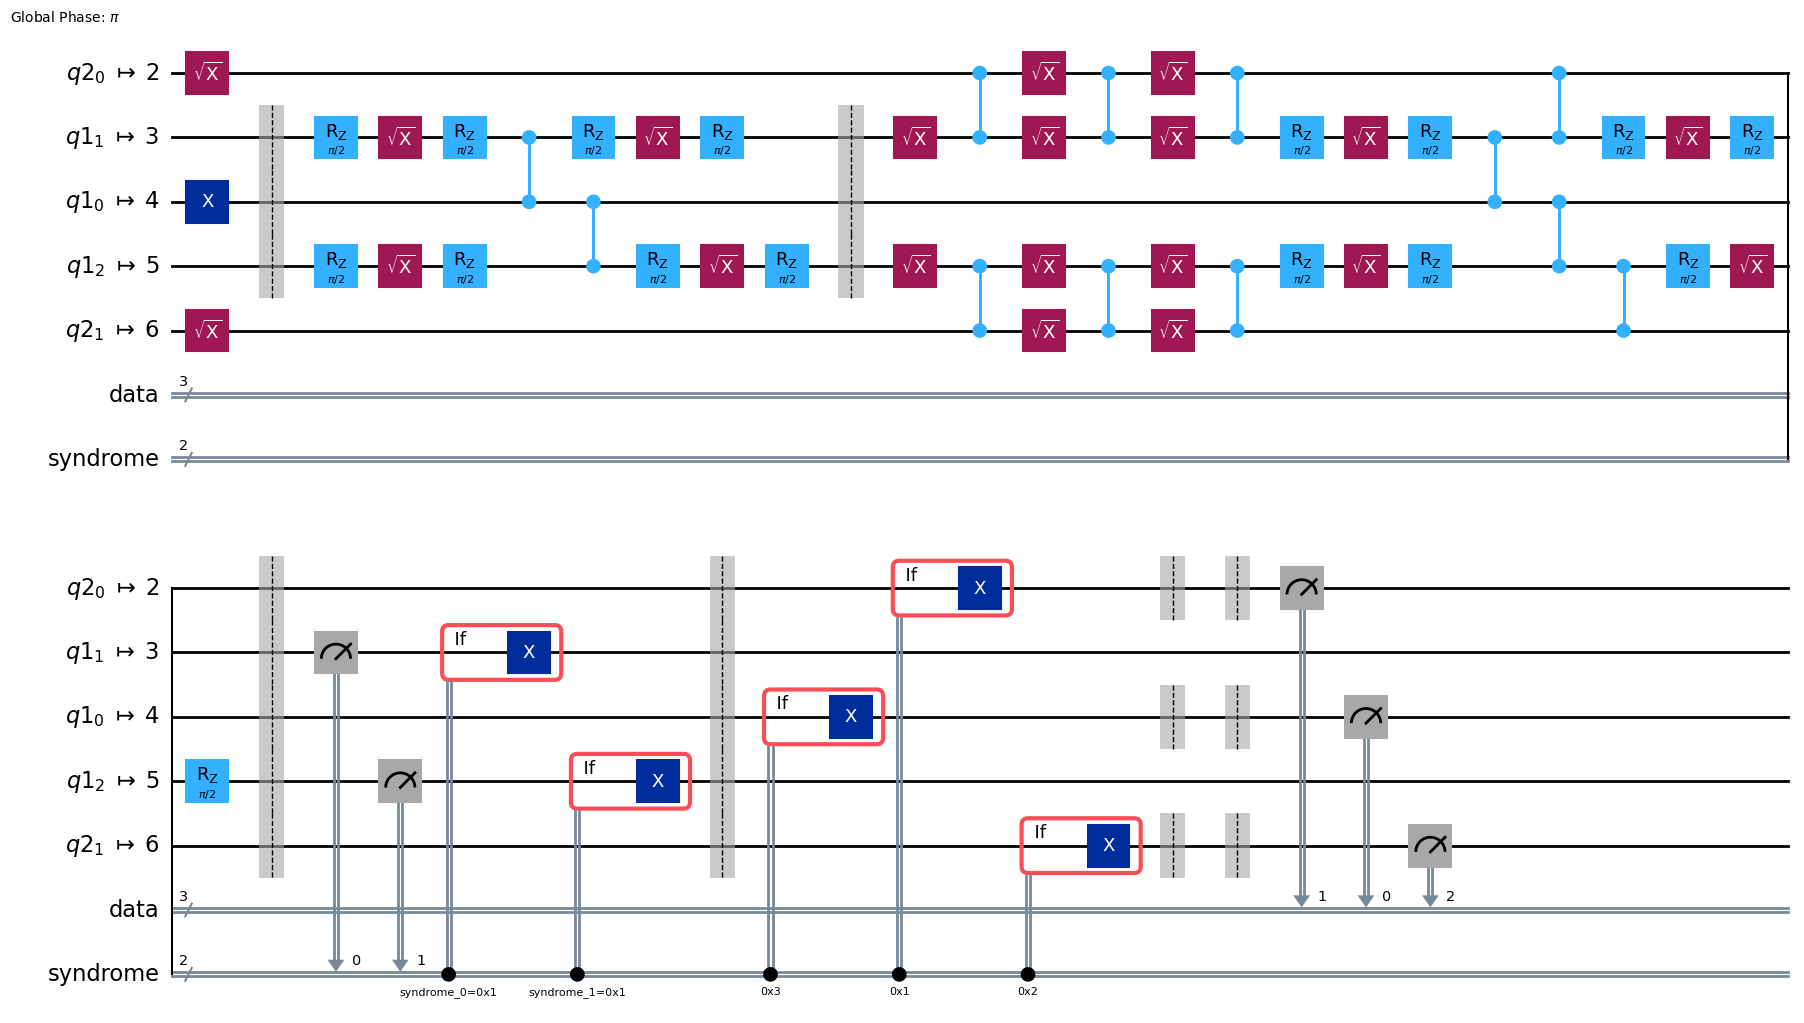

In [3]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
isa_circuit = pm.run(circuit)

isa_circuit.draw("mpl", style="iqp", idle_wires=False)

In [4]:
no_correction_circuit = build_error_correction_sequence(apply_correction=False)
isa_no_correction_circuit = pm.run(no_correction_circuit)

## Step 3. Execute using Qiskit primitives

In [5]:
sampler_no_correction = Sampler(backend)
job_no_correction = sampler_no_correction.run([isa_no_correction_circuit], shots=1000)
result_no_correction = job_no_correction.result()[0]

sampler_with_correction = Sampler(backend)
job_with_correction = sampler_with_correction.run([isa_circuit], shots=1000)
result_with_correction = job_with_correction.result()[0]

print(f"Data (no correction):\n{result_no_correction.data.data.get_counts()}")
print(f"Syndrome (no correction):\n{result_no_correction.data.syndrome.get_counts()}")

Data (no correction):
{'111': 956, '011': 13, '110': 17, '101': 10, '100': 1, '010': 2, '000': 1}
Syndrome (no correction):
{'00': 950, '01': 23, '10': 20, '11': 7}


In [6]:
print(f"Data (corrected):\n{result_with_correction.data.data.get_counts()}")
print(f"Syndrome (corrected):\n{result_with_correction.data.syndrome.get_counts()}")

Data (corrected):
{'111': 944, '011': 22, '110': 10, '101': 19, '010': 3, '000': 2}
Syndrome (corrected):
{'00': 975, '01': 10, '10': 14, '11': 1}


## Step 4. Post-process and decode the result

In [7]:
def decode_result(data_counts, syndrome_counts):
    shots = sum(data_counts.values())
    success_trials = data_counts.get("000", 0) + data_counts.get("111", 0)
    failed_trials = shots - success_trials
    error_correction_events = shots - syndrome_counts.get("00", 0)

    print(f"Bit flip errors were detected/corrected on {error_correction_events}/{shots} trials.")
    print(f"A final parity error was detected on {failed_trials}/{shots} trials.")

In [8]:
# Non-corrected marginalized results
data_result = result_no_correction.data.data.get_counts()
marginalized_syndrome_result = result_no_correction.data.syndrome.get_counts()

print(f"Completed bit code experiment data measurement counts (no correction): {data_result}")
print(f"Completed bit code experiment syndrome measurement counts (no correction): {marginalized_syndrome_result}")
decode_result(data_result, marginalized_syndrome_result)

Completed bit code experiment data measurement counts (no correction): {'111': 956, '011': 13, '110': 17, '101': 10, '100': 1, '010': 2, '000': 1}
Completed bit code experiment syndrome measurement counts (no correction): {'00': 950, '01': 23, '10': 20, '11': 7}
Bit flip errors were detected/corrected on 50/1000 trials.
A final parity error was detected on 43/1000 trials.


In [9]:
# Corrected marginalized results
corrected_data_result = result_with_correction.data.data.get_counts()
corrected_syndrome_result = result_with_correction.data.syndrome.get_counts()

print(f"Completed bit code experiment data measurement counts (corrected): {corrected_data_result}")
print(f"Completed bit code experiment syndrome measurement counts (corrected): {corrected_syndrome_result}")
decode_result(corrected_data_result, corrected_syndrome_result)

Completed bit code experiment data measurement counts (corrected): {'111': 944, '011': 22, '110': 10, '101': 19, '010': 3, '000': 2}
Completed bit code experiment syndrome measurement counts (corrected): {'00': 975, '01': 10, '10': 14, '11': 1}
Bit flip errors were detected/corrected on 25/1000 trials.
A final parity error was detected on 54/1000 trials.


# E